In [13]:
import pandas as pd

# Load the dataset
df = pd.read_csv('senate_stock_discosures.csv')

# Convert the transaction date to datetime format for proper time-series analysis
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Display the top 5 senators by transaction volume
print("--- Top 5 Senators by Transaction Volume ---")
print(df['last_name'].value_counts().head(5))

# Display the top 5 most traded tickers
print("\n--- Top 5 Traded Tickers ---")
print(df['ticker'].value_counts().head(5))



--- Top 5 Senators by Transaction Volume ---
last_name
Tuberville    1094
Capito         571
Whitehouse     532
Carper         499
Wyden          255
Name: count, dtype: int64

--- Top 5 Traded Tickers ---
ticker
AAPL    109
MSFT     94
CLF      91
PYPL     63
INTC     62
Name: count, dtype: int64


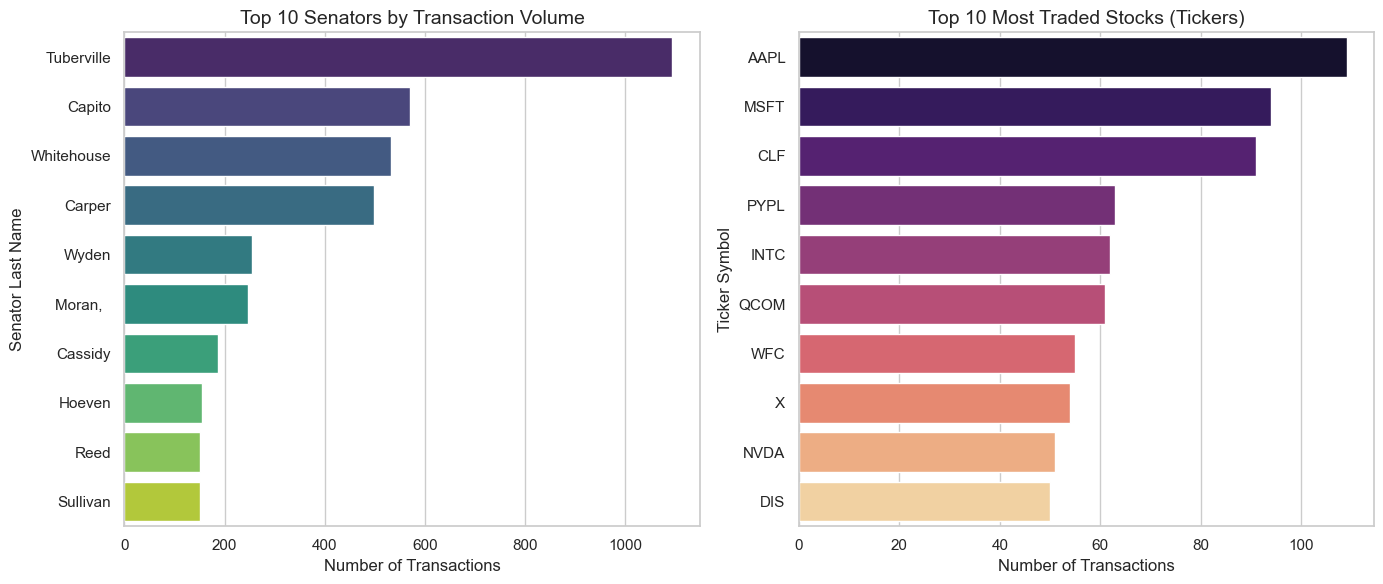

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configure general aesthetics for the plots
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

# Plot 1: Top 10 Senators by transaction count
plt.subplot(1, 2, 1)
top_senators = df['last_name'].value_counts().head(10)
sns.barplot(x=top_senators.values, y=top_senators.index, hue=top_senators.index, legend=False, palette='viridis')
plt.title('Top 10 Senators by Transaction Volume', fontsize=14)
plt.xlabel('Number of Transactions', fontsize=12)
plt.ylabel('Senator Last Name', fontsize=12)

# Plot 2: Top 10 Tickers by transaction count
plt.subplot(1, 2, 2)
top_tickers = df['ticker'].value_counts().head(10)
sns.barplot(x=top_tickers.values, y=top_tickers.index, hue=top_tickers.index, legend=False, palette='magma')
plt.title('Top 10 Most Traded Stocks (Tickers)', fontsize=14)
plt.xlabel('Number of Transactions', fontsize=12)
plt.ylabel('Ticker Symbol', fontsize=12)

# Ensure layout is neat and display the plots
plt.tight_layout()
plt.show()



In [15]:
import scipy.stats as stats

# Extract the upper bounds of asset values for Purchase and Sale transactions
purchases = df[df['transaction'].str.contains('Purchase', na=False)]['asset_value_high']
sales = df[df['transaction'].str.contains('Sale', na=False)]['asset_value_high']

# Perform Welch's t-test (assuming unequal variances) to compare investment sizes
t_stat, p_value = stats.ttest_ind(purchases, sales, equal_var=False)

# Print the statistical results
print("--- Hypothesis Test Results ---")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")
print("-" * 30)

# Evaluate the null hypothesis
if p_value < 0.05:
    print("Conclusion: Reject H0")
    print("There is a statistically significant difference between the investment amounts of purchase and sale transactions.")
else:
    print("Conclusion: Fail to reject H0")
    print("There is no statistically significant difference between the investment amounts of purchase and sale transactions.")
    

--- Hypothesis Test Results ---
T-Statistic: 0.5963
P-Value: 0.5510
------------------------------
Conclusion: Fail to reject H0
There is no statistically significant difference between the investment amounts of purchase and sale transactions.
